# F2-statistics and population structure heatmap (AADR dataset)

This notebook reproduces the R/`admixtools` workflow from the *Fixation index $F_{st}$* slide, adapted to run on **Google Colab**.

It will:
1. Install `conda` on Colab via `condacolab`
2. Install R and the required R packages (`admixtools`, `tidyverse`, `pheatmap`) on the fly
3. Mount your Google Drive and move into the AADR data folder
4. Compute pairwise **F2-statistics** with `admixtools::extract_f2()` / `read_f2()`
5. Plot the pairwise F2 matrix as a clustered heatmap, in a **landscape** layout

> **Note on runtime:** Step 2 (`condacolab.install()`) automatically **restarts the Colab runtime**. This is expected — after it restarts, just continue running the notebook from the next cell onward (you do not need to re-run the `condacolab.install()` cell itself).

## 1. Install conda (condacolab)

In [9]:
!pip install -q condacolab
import condacolab
condacolab.install()


✨🍰✨ Everything looks OK!


The cell above restarts the runtime automatically. Once it has restarted, continue by running the cell below to confirm conda is working, then proceed with the rest of the notebook.

In [10]:
import condacolab
condacolab.check()


✨🍰✨ Everything looks OK!


## 2. Install R and the required R/Python packages

In [ ]:
# Core R + dependencies needed by the admixtools R package, via conda-forge
!mamba install -y -c conda-forge \
    r-base=4.3 \
    r-tidyverse \
    r-devtools \
    r-data.table \
    r-rcpp \
    r-rcpparmadillo \
    r-igraph \
    r-matrix \
    r-pheatmap

[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   7%
conda-forge/noarch     9%[+] 0.3s
conda-forge/linux-64  13%
conda-forge/noarch    20%[+] 0.4s
conda-forge/linux-64  19%
conda-forge/noarch    34%[+] 0.5s
conda-forge/linux-64  24%
conda-forge/noarch    43%[+] 0.6s
conda-forge/linux-64  28%
conda-forge/noarch    51%[+] 0.7s
conda-forge/linux-64  30%
conda-forge/noarch    60%[+] 0.8s
conda-forge/linux-64  35%
conda-forge/noarch    65%[+] 0.9s
conda-forge/linux-64  40%
conda-forge/noarch    76%[+] 1.0s
conda-forge/linux-64  45%
conda-forge/noarch    86%conda-forge/noarch                                
[+] 1.1s
conda-forge/linux-64  50%[+] 1.2s
conda-forge/linux-64  56%[+] 1.3s
conda-forge/linux-64  63%[+] 1.4s
conda-forge/linux-64  70%[+] 1.5s
conda-forge/linux-64  73%[+] 1.6s
conda-forge/linux-64  79%[+] 1.7s
conda-forge/linux-64  84%[+] 1.8s
conda-forge/linux-64  90%[+] 1.9s
conda-forge/linux-64  96%conda-forge/linux-64              

In [11]:
# in case R magic is not installed
# Uninstall all rpy2-related packages
!pip uninstall rpy2 rpy2-rinterface rpy2-robjects -y

# Install a known-working version
!pip install rpy2==3.5.1

Found existing installation: rpy2 3.5.1
Uninstalling rpy2-3.5.1:
  Successfully uninstalled rpy2-3.5.1
  Using cached rpy2-3.5.1-cp313-cp313-linux_x86_64.whl


In [2]:
%load_ext rpy2.ipython

In [4]:
# Install pgenlibr and the main R dependencies through conda
!mamba install -y -c conda-forge \
    r-pgenlibr \
    r-remotes \
    r-tidyverse \
    r-pheatmap \
    r-future \
    r-future.apply \
    r-furrr

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache
[+] 0.0s
[+] 0.0s

Pinned packages:

  - python=3.13

Pinned packages:

  - python_abi[version="=3.13",build="*cp313*"]

Pinned packages:

  - cuda-version*.*

Pinned packages:

  - python=3.13


Transaction

  Prefix: /usr/local

  Updating specs:

   - r-pgenlibr
   - r-remotes
   - r-tidyverse
   - r-pheatmap
   - r-future
   - r-future.apply
   - r-furrr


  Package               Version  Build             Channel           Size
───────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────

  + r-cliapp              0.1.2  r45hc72bb7e_2     conda-forge      249kB
  + r-codetools          0.2_20  r45hc72bb7e_2     conda-forge      109kB
  + r-filelock            1.0.3  r45h54b55ab_2     conda-forge       34kB
  + r-furrr               0.4.0  

In [5]:
%%R
# admixtools (ADMIXTOOLS 2) is not on conda-forge/CRAN, so install it from GitHub
if (!requireNamespace("admixtools", quietly = TRUE)) {
  devtools::install_github("uqrmaie1/admixtools", upgrade = "never")
}

library(admixtools)
library(tidyverse)
library(pheatmap)

cat("admixtools version:", as.character(packageVersion("admixtools")), "\n")


R[write to console]: Downloading GitHub repo uqrmaie1/admixtools@HEAD



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpZweSjU/remotes18d713352d2a/uqrmaie1-admixtools-472d04e/DESCRIPTION’ ... OK
* preparing ‘admixtools’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘admixtools_2.0.10.tar.gz’



R[write to console]: Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

R[write to console]: Error: package or namespace load failed for ‘admixtools’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 namespace ‘rlang’ 1.1.6 is already loaded, but >= 1.1.7 is required

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package ‘admixtools’ was built under R version 4.5.2 




Error: package or namespace load failed for ‘admixtools’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 namespace ‘rlang’ 1.1.6 is already loaded, but >= 1.1.7 is required


RInterpreterError: Failed to parse and evaluate line '# admixtools (ADMIXTOOLS 2) is not on conda-forge/CRAN, so install it from GitHub\nif (!requireNamespace("admixtools", quietly = TRUE)) {\n  devtools::install_github("uqrmaie1/admixtools", upgrade = "never")\n}\n\nlibrary(admixtools)\nlibrary(tidyverse)\nlibrary(pheatmap)\n\ncat("admixtools version:", as.character(packageVersion("admixtools")), "\\n")\n'.
R error message: 'Error: package or namespace load failed for ‘admixtools’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):\n namespace ‘rlang’ 1.1.6 is already loaded, but >= 1.1.7 is required'

In [6]:
%%R
install.packages("rlang", repos = "https://cloud.r-project.org")

R[write to console]: Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/rlang_1.3.0.tar.gz'

R[write to console]: Content type 'application/x-gzip'
R[write to console]:  length 784080 bytes (765 KB)

R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[wri

In [3]:
%%R
library(rlang)
packageVersion("rlang")

[1] ‘1.3.0’


In [4]:
%%R
library(admixtools)
packageVersion("admixtools")

[1] ‘2.0.10’


## 3. Mount Google Drive and move into the AADR folder

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
import os

aadr_dir = '/content/drive/MyDrive/PopGen_PopStructure/AADR'
os.chdir(aadr_dir)
print("Working directory:", os.getcwd())
print(os.listdir('.'))


Working directory: /content/drive/MyDrive/PopGen_PopStructure/AADR
['AADR.geno', 'AADR.ind', 'AADR.snp']


## 4. Compute pairwise F2-statistics

This follows the slide's R code directly: `extract_f2()` reads the AADR genotype files (expected as `AADR.geno` / `AADR.ind` / `AADR.snp`, or PLINK-format equivalents, in the current working directory) and precomputes pairwise F2-statistics into the `f2_AADR` folder.

> **Tip:** On the full AADR dataset this step can be slow/memory-heavy. If it's too slow on Colab, restrict to a subset of populations with `extract_f2("AADR", outdir = "f2_AADR", pops = my_pops)`.

In [7]:
%%R
# Confirm R's working directory matches the Python one (rpy2 shares the process, but let's be explicit)
cat("R working directory:", getwd(), "\n")

# Extract F2 statistics (skips recomputation if already extracted)
if (!dir.exists("f2_AADR")) {
  admixtools::extract_f2("AADR", outdir = "f2_AADR")
}

f2_aadr <- read_f2("f2_AADR")

# Fst, computed the same way as on the slide
fst_aadr <- fst(f2_aadr)
fst_aadr

R working directory: /content/drive/MyDrive/PopGen_PopStructure/AADR 
ℹ Reading allele frequencies from EIGENSTRAT files...
ℹ Reading part 1 of 100...
ℹ Reading part 2 of 100...
ℹ Reading part 3 of 100...
ℹ Reading part 4 of 100...
ℹ Reading part 5 of 100...
ℹ Reading part 6 of 100...
ℹ Reading part 7 of 100...
ℹ Reading part 8 of 100...
ℹ Reading part 9 of 100...
ℹ Reading part 10 of 100...
ℹ Reading part 11 of 100...
ℹ Reading part 12 of 100...
ℹ Reading part 13 of 100...
ℹ Reading part 14 of 100...
ℹ Reading part 15 of 100...
ℹ Reading part 16 of 100...
ℹ Reading part 17 of 100...
ℹ Reading part 18 of 100...
ℹ Reading part 19 of 100...
ℹ Reading part 20 of 100...
ℹ Reading part 21 of 100...
ℹ Reading part 22 of 100...
ℹ Reading part 23 of 100...
ℹ Reading part 24 of 100...
ℹ Reading part 25 of 100...
ℹ Reading part 26 of 100...
ℹ Reading part 27 of 100...
ℹ Reading part 28 of 100...
ℹ Reading part 29 of 100...
ℹ Reading part 30 of 100...
ℹ Reading part 31 of 100...
ℹ Reading part 32

## 5. Build the pairwise F2 matrix and plot the heatmap (landscape layout)

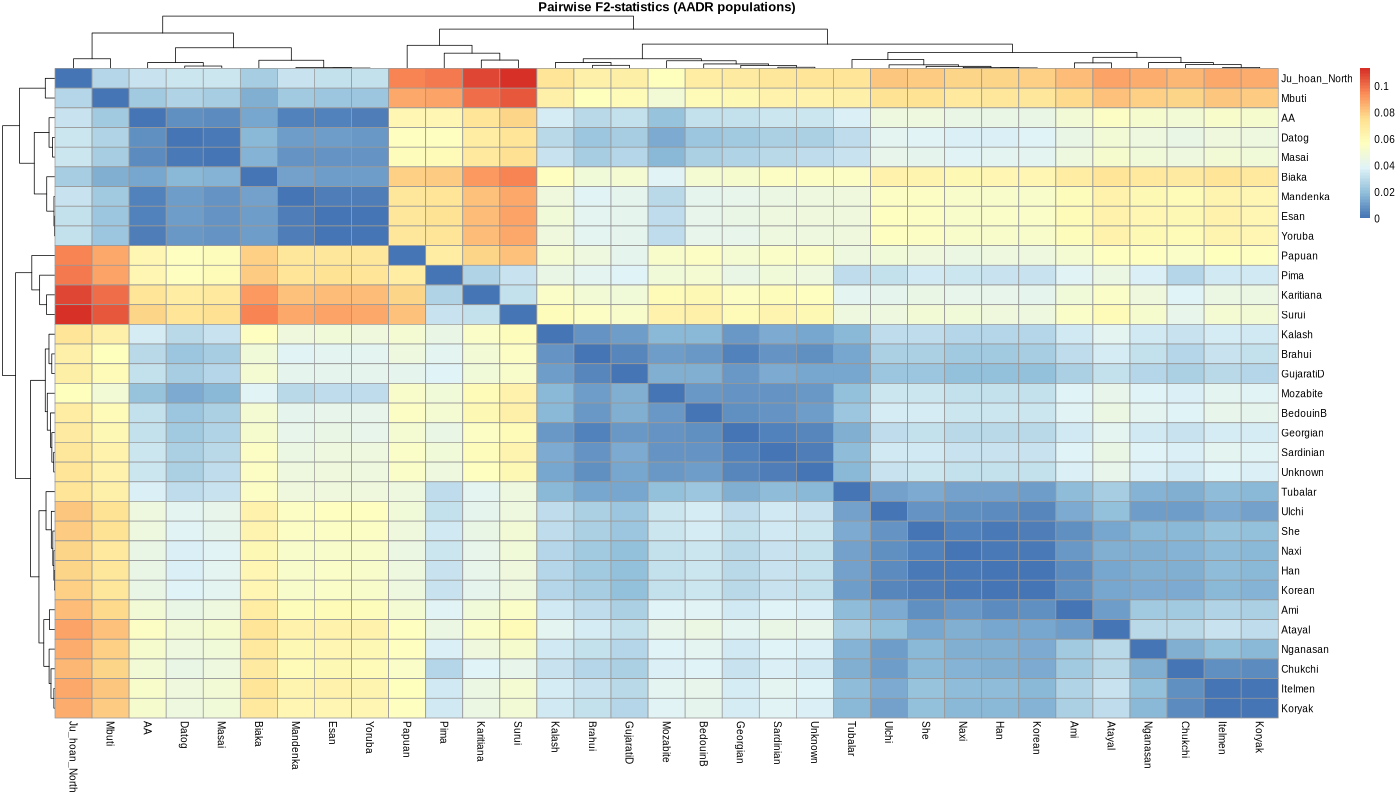

In [14]:
%%R -w 1400 -h 800 -u px

library("pheatmap")

mat <- f2(f2_aadr, unique_only = FALSE) %>%
  dplyr::select(-se) %>%
  tidyr::pivot_wider(
    names_from = pop2,
    values_from = est
  ) %>%
  tibble::column_to_rownames("pop1") %>%
  as.matrix()

pheatmap(
  mat,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  main = "Pairwise F2-statistics (AADR populations)"
)

---
### Notes
- The `-w 1400 -h 800 -u px` on the final `%%R` cell sets a wide (landscape) figure size for the heatmap; adjust these values to taste.
- If you re-run the notebook later, the `if (!dir.exists("f2_AADR"))` check avoids recomputing F2-statistics from scratch.
- If `extract_f2()` fails to find your genotype files, double-check that `AADR.geno`, `AADR.ind`, and `AADR.snp` (or equivalent PLINK files) are directly inside `/content/drive/MyDrive/PopGen_PopStructure/AADR`.

In [15]:
# ----- 2. Run nbconvert -------------------------------------------
# Convert the notebook on disk to a standalone HTML file.
!jupyter nbconvert --to html /content/drive/MyDrive/PopGen_PopStructure/F2_statistics_AADR_heatmap.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PopGen_PopStructure/F2_statistics_AADR_heatmap.ipynb to html
/usr/local/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 581798 bytes to /content/drive/MyDrive/PopGen_PopStructure/F2_statistics_AADR_heatmap.html
